# Exercise 3: Neural networks in PyTorch

In this exercise you’ll implement small neural-network building blocks from scratch and use them to train a simple classifier.

You’ll cover:
- **Basic layers**: Linear, Embedding, Dropout
- **Normalization**: LayerNorm and RMSNorm
- **MLPs + residual**: composing layers into deeper networks
- **Classification**: generating a learnable dataset, implementing cross-entropy from logits, and writing a minimal training loop

As before: fill in all `TODO`s without changing function names or signatures.
Use small sanity checks and compare to PyTorch reference implementations when useful.

In [42]:
from __future__ import annotations

import torch
from torch import nn

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu" )

## Basic layers

In this section you’ll implement a few core layers that appear everywhere:

### `Linear`
A fully-connected layer that follows nn.Linear conventions:  
`y = x @ Wᵀ + b`

Important details:
- Parameters should be registered as `nn.Parameter`
- Store weight as (out_features, in_features) like nn.Linear.
- The forward pass should support leading batch dimensions: `x` can be shape `(..., in_features)`

### `Embedding`
An embedding table maps integer ids to vectors:
- input: token ids `idx` of shape `(...,)`
- output: vectors of shape `(..., embedding_dim)`

This is essentially a learnable lookup table.

### `Dropout`
Dropout randomly zeroes activations during training to reduce overfitting.
Implementation details:
- Only active in `model.train()` mode
- In training: drop with probability `p` and scale the kept values by `1/(1-p)` so the expected value stays the same
- In eval: return the input unchanged

## Instructions
- Do not use PyTorch reference modules for the parts you implement (e.g. don’t call nn.Linear inside your Linear).
- You may use standard tensor ops that you learned before (matmul, sum, mean, rsqrt, indexing, etc.).
- Use a parameter initialization method of your choice. We recommend something like Xavier-uniform.


In [2]:
class Linear(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        # TODO: initialize parameters
        weight = torch.nn.init.xavier_uniform_(torch.empty(size=(out_features,in_features)))
        self.weight = torch.nn.Parameter(data=weight)
        if bias:
            bias = torch.nn.init.xavier_uniform_(torch.empty(size=(1,out_features)))
            self.bias = torch.nn.Parameter(data=bias)
        else:
            self.bias = torch.zeros(size=(1, out_features))
            
            

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., in_features)
        return: (..., out_features)
        """
        # TODO: implement
        return x @ self.weight.T + self.bias

In [3]:
class Embedding(nn.Module):
    def __init__(self, num_embeddings: int, embedding_dim: int):
        super().__init__()
        # TODO: initialize
        weight = torch.nn.init.xavier_uniform_(torch.empty(size=(num_embeddings,embedding_dim)))
        self.weight = torch.nn.Parameter(data=weight)
    def forward(self, idx: torch.Tensor) -> torch.Tensor:
        """
        idx: (...,) int64
        return: (..., embedding_dim)
        """
        # TODO: implement (index into weight)
        return self.weight[idx]

In [4]:
class Dropout(nn.Module):
    def __init__(self, p: float):
        super().__init__()
        self.dropout = p

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        In train mode: drop with prob p and scale by 1/(1-p).
        In eval mode: return x unchanged.
        """
        # TODO: implement without using nn.Dropout
        if self.training: # is in train mode?
            mask = torch.rand_like(x) < self.dropout
            x[mask] = 0
            x.mul_(other=1 / (1 - self.dropout))
            return x
        else:
            return x

## Normalization

Normalization layers help stabilize training by controlling activation statistics.

### LayerNorm
LayerNorm normalizes each example across its **feature dimension** (the last dimension):

- compute mean and variance over the last dimension
- normalize: `(x - mean) / sqrt(var + eps)`
- apply learnable per-feature scale and shift (`weight`, `bias`)

**In this exercise, assume `elementwise_affine=True` (always include `weight` and `bias`).**  
`weight` and `bias` each have shape `(D,)`.

LayerNorm is widely used in transformers because it does not depend on batch statistics.

### RMSNorm
RMSNorm is similar to LayerNorm but normalizes using only the root-mean-square:
- `x / sqrt(mean(x^2) + eps)` over the last dimension
- usually includes a learnable scale (`weight`)
- no mean subtraction

RMSNorm is popular in modern LLMs because it's faster.


In [26]:
class LayerNorm(nn.Module):
    def __init__(
        self, normalized_shape: int, eps: float = 1e-5, elementwise_affine: bool = True
    ):
        super().__init__()
        # TODO: implement
        self.weight = torch.nn.Parameter(torch.empty(size=(normalized_shape,)))
        self.bias = torch.nn.Parameter(torch.empty(size=(normalized_shape,)))
        self.eps = eps
        self.elementwise_affine = elementwise_affine

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Normalize over the last dimension.
        x: (..., D)
        """
        # TODO: implement
        mean = torch.mean(x, dim=-1)
        var = torch.var(x, dim=-1)
        x_hat = (x - mean) / torch.sqrt(var + self.eps)
        if self.elementwise_affine:
            return self.weight * x_hat + self.bias
        else:
            return x_hat

In [27]:
class RMSNorm(nn.Module):
    def __init__(self, normalized_shape: int, eps: float = 1e-8):
        super().__init__()
        # TODO: implement
        self.weight = torch.nn.Parameter(torch.empty(size=(normalized_shape,)))
        self.eps = eps

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        RMSNorm: x / sqrt(mean(x^2) + eps) * weight
        over the last dimension.
        """
        # TODO: implement
        return x / (torch.sqrt(torch.mean(x ** 2, dim=-1) + self.eps)) * self.weight

## MLPs and residual networks

Now you’ll build larger networks by composing layers.

### MLP
An MLP is a stack of `depth` Linear layers with non-linear activations (use GELU) in between.
In this exercise you’ll support:
- configurable depth
- a hidden dimension
- optional LayerNorm between layers (a common stabilization trick)

A key skill is building networks using `nn.ModuleList` / `nn.Sequential` while keeping shapes consistent.

### Transformer-style FeedForward (FFN)
A transformer block contains a position-wise feedforward network:
- `D -> 4D -> D` (by default)
- activation is typically **GELU**

This is essentially an MLP applied independently at each token position.

### Residual wrapper
Residual connections are the simplest form of “skip connection”:
- output is `x + fn(x)`

They improve gradient flow and allow training deeper networks more reliably.

In [28]:
class MLP(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        out_dim: int,
        depth: int,
        use_layernorm: bool = False,
    ):
        super().__init__()
        # TODO: build modules (list of Linear + activation)
        # Optionally insert LayerNorm between layers.
        curr_dim = in_dim
        next_dim = hidden_dim
        layers = nn.ModuleList()
        for i in range(depth):
            if i == depth - 1:
                layers.append(nn.Sequential(nn.Linear(curr_dim, next_dim)))
                continue
            if use_layernorm:
                layers.append(nn.Sequential(
                  nn.Linear(curr_dim, next_dim),
                  nn.GELU(),
                  LayerNorm(next_dim)
              )) 
            
            else:
                layers.append(nn.Sequential(
                  nn.Linear(curr_dim, next_dim),
                  nn.GELU(),
              )) 

            curr_dim = next_dim
            if i == depth - 2:
                next_dim = out_dim

                 
        
        self.mlp = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: implement
        return self.mlp(x)
    
model = MLP(3,6,1,5,True)
print(model)

MLP(
  (mlp): Sequential(
    (0): Sequential(
      (0): Linear(in_features=3, out_features=6, bias=True)
      (1): GELU(approximate='none')
      (2): LayerNorm()
    )
    (1): Sequential(
      (0): Linear(in_features=6, out_features=6, bias=True)
      (1): GELU(approximate='none')
      (2): LayerNorm()
    )
    (2): Sequential(
      (0): Linear(in_features=6, out_features=6, bias=True)
      (1): GELU(approximate='none')
      (2): LayerNorm()
    )
    (3): Sequential(
      (0): Linear(in_features=6, out_features=6, bias=True)
      (1): GELU(approximate='none')
      (2): LayerNorm()
    )
    (4): Sequential(
      (0): Linear(in_features=6, out_features=1, bias=True)
    )
  )
)


In [29]:
class FeedForward(nn.Module):
    """
    Transformer-style FFN: D -> 4D -> D (default)
    """

    def __init__(self, d_model: int, d_ff: int | None = None):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        # TODO: create two Linear layers and choose an activation (GELU)
        self.ffn = nn.Sequential(
            nn.Linear(d_model,d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: implement
        return self.ffn(x)

In [30]:
class Residual(nn.Module):
    def __init__(self, fn: nn.Module):
        super().__init__()
        # TODO: implement
        self.fn = fn

    def forward(self, x: torch.Tensor, *args, **kwargs) -> torch.Tensor:
        # TODO: return x + fn(x, ...)
        return x + self.fn(x,*args,**kwargs)

## Classification problem

In this section you’ll put everything together in a minimal MNIST classification experiment.

You will:
1) download and load the MNIST dataset
2) implement cross-entropy from logits (stable, using log-softmax)
3) build a simple MLP-based classifier (flatten MNIST images first)
4) write a minimal training loop
5) report train loss curve and final accuracy

The goal here is not to reach state-of-the-art accuracy, but to understand the full pipeline:
data → model → logits → loss → gradients → parameter update.

### Model notes
- We want you to combine the MLP we implemented above with the classification head we define below into one model 

### MNIST notes
- MNIST images are `28×28` grayscale.
- After `ToTensor()`, each image has shape `(1, 28, 28)` and values in `[0, 1]`.
- For an MLP classifier, we flatten to a vector of length `784`.

## Deliverables
- Include a plot of your train loss curve in the video submission as well as a final accuracy. 
- **NOTE** Here we don't grade on model performance but we expect you to achieve at least 70% accuracy to confirm a correct model implementation.

In [120]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [121]:
transform = transforms.ToTensor()  # -> float32 in [0,1], shape (1, 28, 28)

train_ds = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="data", train=False, download=True, transform=transform)

# TODO: define the dataloaders
train_loader = DataLoader(dataset=train_ds, batch_size=32, shuffle=True,num_workers=0)
test_loader = DataLoader(dataset=test_ds, batch_size=64, shuffle=False,num_workers=0)

In [122]:
def cross_entropy_from_logits(
    logits: torch.Tensor,
    targets: torch.Tensor,
) -> torch.Tensor:
    """
    Compute mean cross-entropy loss from logits.

    logits: (B, C)
    targets: (B,) int64

    Requirements:
    - Use log-softmax for stability (do not use torch.nn.CrossEntropyLoss, we check this in the autograder).
    """
    # TODO: implement
    # log-softmax implementation
    logits_max = torch.max(logits, dim=1)[0].unsqueeze(1)
    log_softmax = logits - logits_max - torch.log(torch.sum(torch.exp(logits - logits_max)))
    rows = torch.arange(start=0, end=log_softmax.size(0),step=1)
    return - log_softmax[rows,targets]

In [123]:
class ClassificationHead(nn.Module):
    def __init__(self, d_in: int, num_classes: int):
        super().__init__()
        # TODO: implement
        self.linear = nn.Linear(d_in, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., d_in)
        return: (..., num_classes) logits
        """
        # TODO: implement
        return self.linear(x)

In [142]:
def accuracy(loader):
    # TODO: You can use this function to evaluate your model accuracy.
    total = 0
    accuracy = 0
    for x,y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        total += x.shape[0]

        logits = model(x.flatten(1,-1))
        pred = torch.argmax(logits, dim=-1)
        accuracy += (pred==y).sum().item()
    
    accuracy /= total

    print(f"Model's accuracy is: {accuracy}")


In [143]:
def train_classifier(
    model: nn.Module,
    train_data_loader: DataLoader,
    test_data_loader: DataLoader,
    lr: float,
    epochs: int,
    seed: int = 0,
) -> list[float]:
    """
    Minimal training loop for MNIST classification.

    Steps:
    - define optimizer
    - for each epoch:
        - sample minibatches
        - forward -> cross-entropy -> backward -> optimizer step
      - compute test accuracy at the end of each epoch
    - return list of training losses (one per update step)

    Requirements:
    - call model.train() during training and model.eval() during evaluation
    - do not use torch.nn.CrossEntropyLoss (use your cross_entropy_from_logits)
    """
    # TODO: implement
    torch.manual_seed(seed)
    losses = []
    optimizer = torch.optim.AdamW(params=model.parameters(), lr=lr)
    model.train()

    for i in range(epochs):
        total = 0
        curr_loss = 0
        #  --- TRAINING ---
        for x,y in train_data_loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            optimizer.zero_grad()
            logits = model(x.flatten(1,-1))
            loss = cross_entropy_from_logits(logits, y).sum()

            # --- Training statistics --- 
            curr_loss += loss.item()
            total += x.shape[0]
            
            # --- Optimization ---
            loss.backward()
            optimizer.step()
        
        losses.append(curr_loss/total)
        print(f"Epoch: {i + 1} Training loss: {losses[i]}")
        accuracy(test_data_loader)
    
    return losses
    


In [160]:
model = nn.Sequential(MLP(784,256,64,3), ClassificationHead(64,10)).to(DEVICE)

lr = 3e-3
epochs = 20

losses = train_classifier(model, train_loader, test_loader, lr, epochs)

Epoch: 1 Training loss: 3.718739341481527
Model's accuracy is: 0.9508
Epoch: 2 Training loss: 3.5985572668711345
Model's accuracy is: 0.9625
Epoch: 3 Training loss: 3.570185008748372
Model's accuracy is: 0.9656
Epoch: 4 Training loss: 3.5530547437032065
Model's accuracy is: 0.9756
Epoch: 5 Training loss: 3.542803477350871
Model's accuracy is: 0.9736
Epoch: 6 Training loss: 3.5325146105448404
Model's accuracy is: 0.976
Epoch: 7 Training loss: 3.5320650015513104
Model's accuracy is: 0.9708
Epoch: 8 Training loss: 3.522427272669474
Model's accuracy is: 0.9747
Epoch: 9 Training loss: 3.5234245988210042
Model's accuracy is: 0.9776
Epoch: 10 Training loss: 3.516879926300049
Model's accuracy is: 0.9732
Epoch: 11 Training loss: 3.517446325937907
Model's accuracy is: 0.9766
Epoch: 12 Training loss: 3.514813269551595
Model's accuracy is: 0.9766
Epoch: 13 Training loss: 3.508968746693929
Model's accuracy is: 0.969
Epoch: 14 Training loss: 3.5108127216339113
Model's accuracy is: 0.9752
Epoch: 15 T

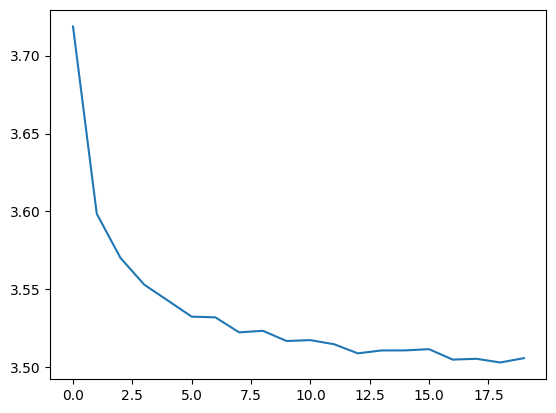

In [161]:
# --- Curve Plot --- #
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, len(losses)-1, len(losses), dtype=int)

y = np.array(losses)[x]

fig, ax = plt.subplots()
ax.plot(x,y)
plt.show()
